In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent
print(PROJECT_DIR)
datapath = PROJECT_DIR / 'data' / 'raw' / 'stocks_panel_daily_qfq_baostock.csv'

df = pd.read_csv(datapath)
df["ticker"] = df["ticker"].astype(str).str.zfill(6)
df["date"] = pd.to_datetime(df["date"])
df.head()


/Users/yimingma/Documents/Quant/a_share_multi_factor_project


,date,ticker,open,high,low,close,volume,amount,pct_change,turnover
0,2016-01-04,000001,7.667784,7.686953,7.175768,7.239666,56349787,660376160.0,-5.5046,0.477377
1,2016-01-05,000001,7.201327,7.393022,7.124649,7.284395,66326995,755531360.0,0.6178,0.561900
2,2016-01-06,000001,7.297174,7.386632,7.278005,7.367462,51570644,591698528.0,1.1404,0.436889
3,2016-01-07,000001,7.290785,7.290785,6.971294,6.990463,17476110,194869493.0,-5.1171,0.148052
4,2016-01-08,000001,7.162988,7.214107,6.964904,7.105480,74752758,831334544.0,1.6453,0.633280


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 642091 entries, 0 to 642090
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        642091 non-null  datetime64[us]
 1   ticker      642091 non-null  str           
 2   open        642091 non-null  float64       
 3   high        642091 non-null  float64       
 4   low         642091 non-null  float64       
 5   close       642091 non-null  float64       
 6   volume      642091 non-null  int64         
 7   amount      642091 non-null  float64       
 8   pct_change  642091 non-null  float64       
 9   turnover    642091 non-null  float64       
dtypes: datetime64[us](1), float64(7), int64(1), str(1)
memory usage: 49.0 MB


In [16]:
df.columns

Index(['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'amount',
       'pct_change', 'turnover'],
      dtype='str')

In [24]:
summary = (df.groupby("ticker")["date"].agg(["min", "max", "count"]).sort_values("count"))

print(summary)



              min        max  count
ticker                             
002920 2017-12-26 2025-12-31   1946
001965 2017-12-25 2025-12-31   1947
600025 2017-12-15 2025-12-31   1953
002916 2017-12-13 2025-12-31   1953
603260 2017-10-30 2025-12-31   1987
...           ...        ...    ...
600015 2016-01-04 2025-12-31   2430
600016 2016-01-04 2025-12-31   2430
600023 2016-01-04 2025-12-31   2430
601225 2016-01-04 2025-12-31   2430
000001 2016-01-04 2025-12-31   2430

[234 rows x 3 columns]


In [18]:
min_obs = int(summary["count"].max() * 0.8)
valid_tickers = summary[summary["count"] >= min_obs].index.tolist()
df = df[df["ticker"].isin(valid_tickers)].copy()
print(f"number of valid stocks: {df['ticker'].nunique()}")

number of valid stocks: 234


In [19]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_ratio

date          0.0
ticker        0.0
open          0.0
high          0.0
low           0.0
close         0.0
volume        0.0
amount        0.0
pct_change    0.0
turnover      0.0
dtype: float64

In [20]:
missing_ratio_byticker = df.groupby("ticker").apply(lambda x: x.isna().mean()).sort_values(by="date", ascending=False)
missing_ratio_byticker.head()

,date,open,high,low,close,volume,amount,pct_change,turnover
ticker,,,,,,,,,
000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
600803,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
600547,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
600570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
600584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
df[["open", "high", "low", "close", "volume", "amount", "turnover"]].describe()

,open,high,low,close,volume,amount,turnover
count,557521.000000,557521.000000,557521.000000,557521.000000,5.575210e+05,5.575210e+05,557521.000000
mean,29.067458,29.589910,28.605529,29.095469,4.929142e+07,8.400876e+08,1.200545
std,88.090202,89.244507,87.027479,88.125570,9.265678e+07,1.358260e+09,1.730519
min,1.031713,1.061474,1.031713,1.041634,5.000000e+02,1.842000e+04,0.002000
25%,6.589711,6.687779,6.500752,6.593248,1.037977e+07,1.955494e+08,0.349100
50%,13.597341,13.808749,13.406896,13.604809,2.380337e+07,4.185827e+08,0.681470
75%,27.063060,27.544285,26.638272,27.083966,5.323557e+07,9.307518e+08,1.349900
max,2268.442109,2303.415656,2178.177050,2279.854530,5.171253e+09,9.003765e+10,70.147134


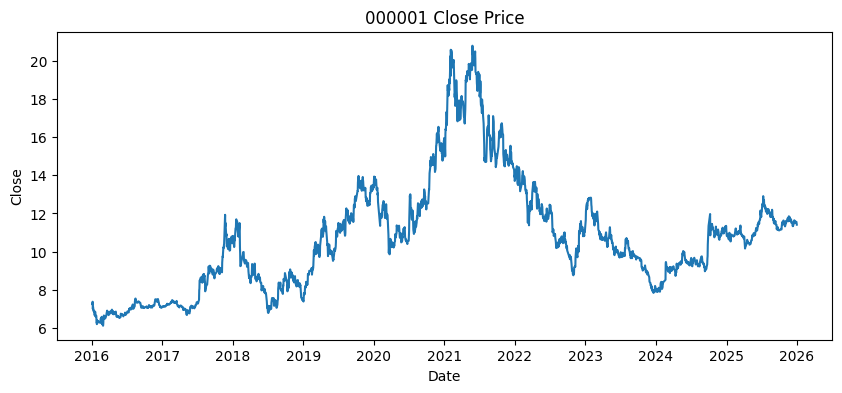

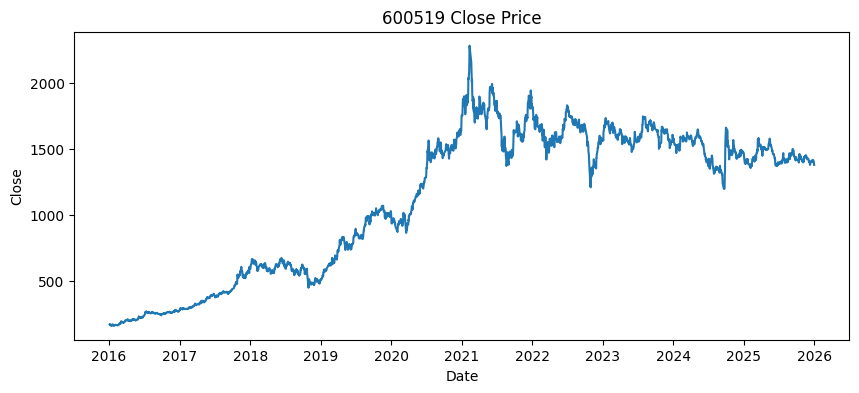

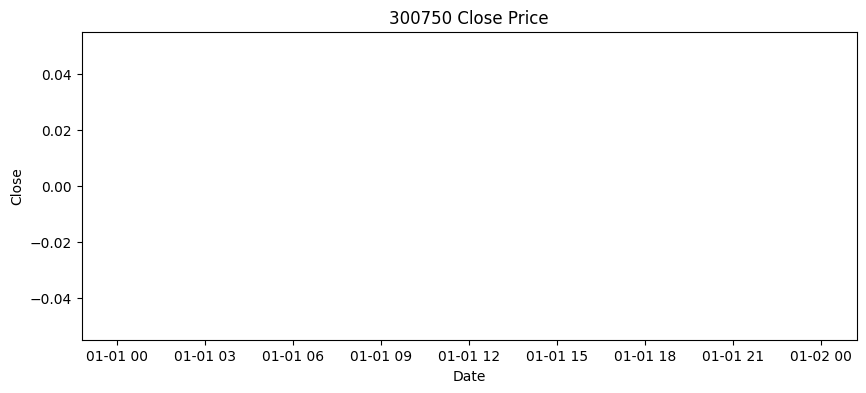

In [22]:
sample_tickers = ["000001", "600519", "300750"]

for ticker in sample_tickers:
    temp = df[df["ticker"] == ticker].sort_values("date")

    plt.figure(figsize=(10, 4))
    plt.plot(temp["date"], temp["close"])
    plt.title(f"{ticker} Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.show()

In [23]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

clean_path = PROCESSED_DIR / "clean_daily_data.csv"

df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
df.to_csv(clean_path, index=False, encoding="utf-8-sig")

print("Saved clean data to:", clean_path)
print(df.shape) 

Saved clean data to: /Users/yimingma/Documents/Quant/a_share_multi_factor_project/data/processed/clean_daily_data.csv
(557521, 10)
